In [1]:
%load_ext autoreload
%autoreload 2

import lusee  as lu
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import SkyCoord, GeocentricMeanEcliptic
from astropy import units as u


/home/anze/venv/luseepy/lib/python3.11/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/anze/.config', but the default location, /home/anze/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


/home/anze/venv/luseepy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.
The croissant.jax interface is deprecated and will be removed in a future release. Please use the croissant interface directly instead.


In [2]:
def _ecliptic_lon_lat_to_ra_dec_deg(lon_deg, lat_deg):
    """Convert ecliptic (lon, lat) to equatorial (ra, dec) in degrees"""

    c = SkyCoord(
        lon=lon_deg*u.deg,
        lat=lat_deg*u.deg,
        frame=GeocentricMeanEcliptic
    )

    eq = c.icrs

    return eq.ra.deg, eq.dec.deg

ecl_lon_deg, ecl_lat_deg = 45.0, 0.0
ra_deg, dec_deg = _ecliptic_lon_lat_to_ra_dec_deg(ecl_lon_deg, ecl_lat_deg)

In [3]:
time_start = "2025-03-01 00:00:00"
time_end = "2025-03-29 00:00:00"  # 28 days later
deltaT_sec = 7200.0  # 2 hours
obs = lu.Observation(
    f"{time_start} to {time_end}",
    deltaT_sec=deltaT_sec,
    lun_lat_deg=0.0,
    lun_long_deg=0.0,
)

In [4]:
type(ra_deg)==np.float32

False

In [5]:
## first sanity check, it the source actually reaching our zenith.a
alt,az = obs.get_track_ra_dec(ra_deg, dec_deg)


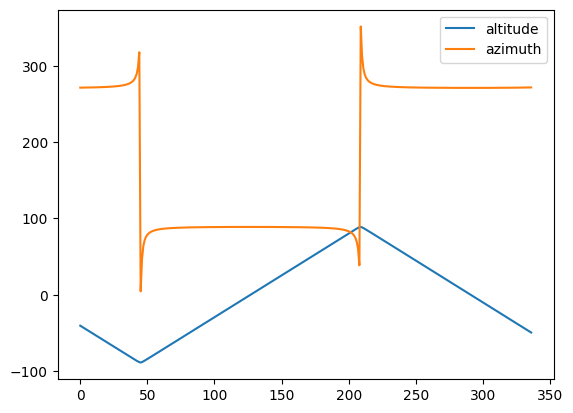

In [6]:
plt.plot(alt/np.pi*180, label="altitude")
plt.plot(az/np.pi*180, label="azimuth")
plt.legend()

In [9]:
sky = lu.SkyModels.HarmonicPointSourceSky(ra_deg=ra_deg, dec_deg=dec_deg,lmax=64*3, freq=[25])
alms = sky.get_alm(0,freq=[25])
sky2 = lu.SkyModels.SingleSourceHealpixSky(ra_deg=ra_deg, dec_deg=dec_deg, Nside=64, freq=[25]) 
alms2 = sky2.get_alm(0,freq=[25])
plt.figure()
mp = hp.alm2map(alms[0], nside=64)
mp/=mp.max()
hp.mollview(mp, title='HarmonicPointSourceSky')
plt.figure()
mp=hp.alm2map(alms2[0], nside=64)
mp/=mp.max()
hp.mollview(mp, title='SingleSourceHealpixSky')

TypeError: only integer scalar arrays can be converted to a scalar index

In [77]:
class GalacticSkyAdapter:
    """Test-only: wraps an equatorial HealpixSky and exposes galactic alms via fixed eq->gal rotation.
    Truncates alms to lmax so they match the simulator/beam (SingleSourceHealpixSky uses 3*Nside-1)."""
    def __init__(self, equatorial_sky, lmax):
        self._sky = equatorial_sky
        self._lmax = lmax
        self.frame = "galactic"
        self.freq = equatorial_sky.freq
        self.Nside = equatorial_sky.Nside
        self._rot = hp.rotator.Rotator(coord=["C", "G"])
        self._alm_size = hp.Alm.getsize(lmax)

    def get_alm(self, ndx, freq):
        alms = self._sky.get_alm(ndx, freq)
        alms = np.atleast_2d(alms)
        out = []
        for a in alms:
            r = self._rot.rotate_alm(a)
            out.append(r[: self._alm_size].copy())
        return out


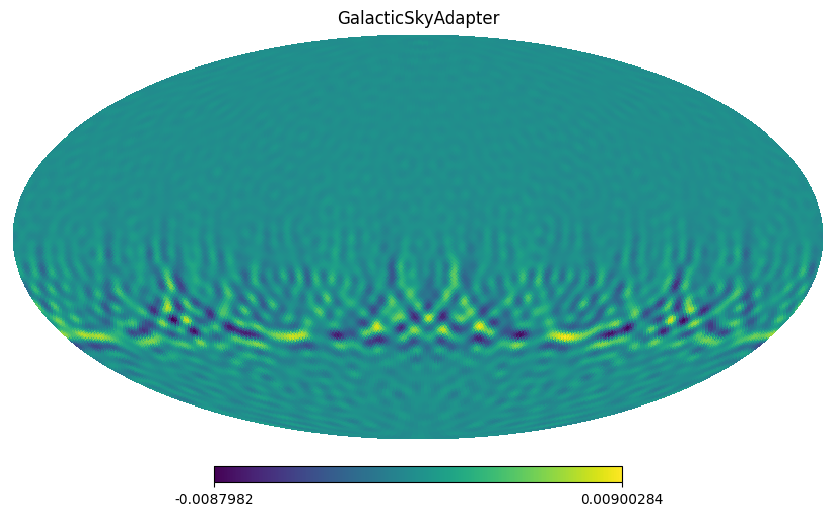

In [82]:
rsky = GalacticSkyAdapter(sky2, lmax=64)
mp = hp.alm2map(rsky.get_alm(0,freq=25)[0], nside=64)
hp.mollview(mp, title='GalacticSkyAdapter')

In [ ]:
sky_eq = lusee.sky.SingleSourceHealpixSky(ra_deg, dec_deg, Nside=nside, freq=freq)
sky = GalacticSkyAdapter(sky_eq, lmax=lmax)

beam = lusee.BeamGauss(
    dec_deg=90.0,
    sigma_deg=10,
    phi_deg=90.0,
    one_over_freq_scaling=False,
    id="beam",
)
beams = [beam]

    # Run DefaultSimulator (topo frame)
    def_sim = lusee.DefaultSimulator(
        obs, beams, sky,
        Tground=Tground,
        combinations=[(0, 0)],
        freq=freq,
        lmax=lmax,
        extra_opts={"plot_sky_and_beam": True, "plot_dir": "/Users/akshatha.vydula/lusee/luseepy/simulation/output/figures", 
        "plot_filename": "sky_beam_healpix_default_single_pixel.png"},
    )
    def_sim.simulate(times=times)

    # Run CroSimulator (MCMF frame)
    cro_sim = lusee.CroSimulator(
        obs, beams, sky,
        Tground=Tground,
        combinations= [(0, 0)],
        freq=freq,
        lmax=lmax,
        extra_opts={"plot_sky_and_beam": True, "plot_dir": "/Users/akshatha.vydula/lusee/luseepy/simulation/output/figures", 
        "plot_filename": "sky_beam_healpix_cro_single_pixel.png"},
    )
    cro_sim.simulate(times=times)

    out_dir = Path(__file__).resolve().parent
    cro_sim.write_fits(str(out_dir / "sim_output_cro_singlepixel_28days.fits"))
    def_sim.write_fits(str(out_dir / "sim_output_default_singlepixel_28days.fits"))


<Figure size 640x480 with 0 Axes>

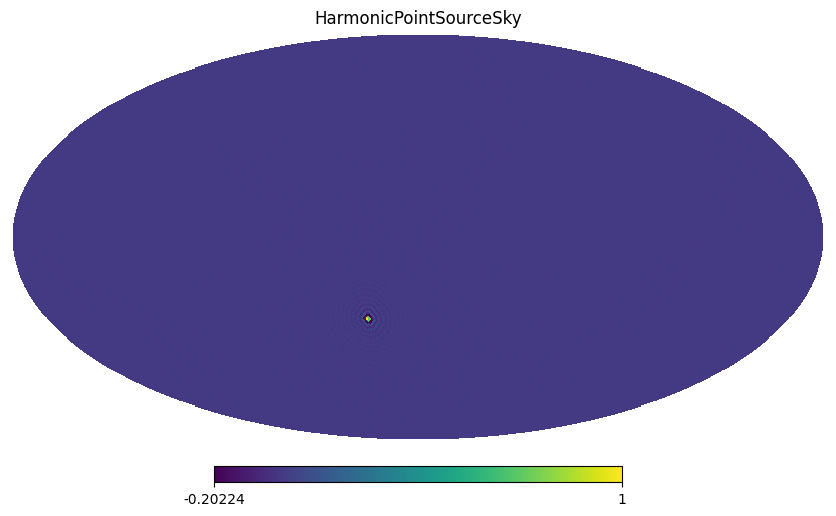

<Figure size 640x480 with 0 Axes>

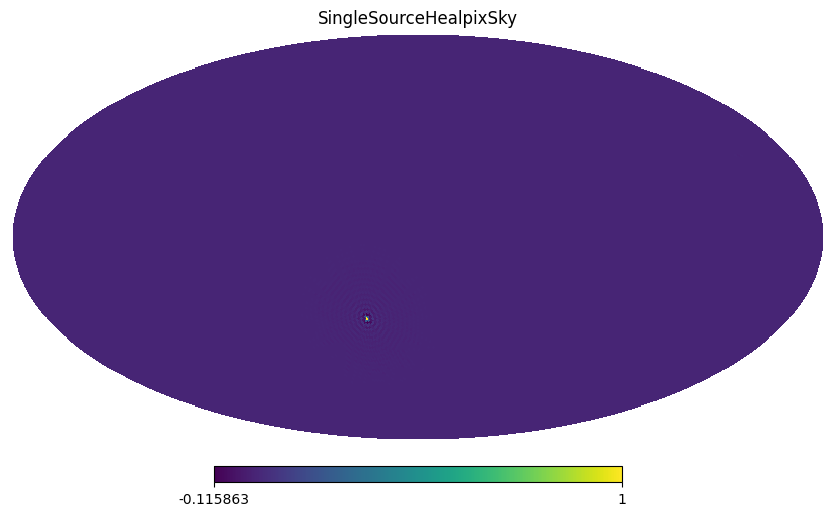

In [12]:
B=lu.BeamGauss(
    dec_deg=60.0,
    sigma_deg=10,
    phi_deg=45.0,       
)

In [13]:
a = B.get_healpix_alm(lmax=64)

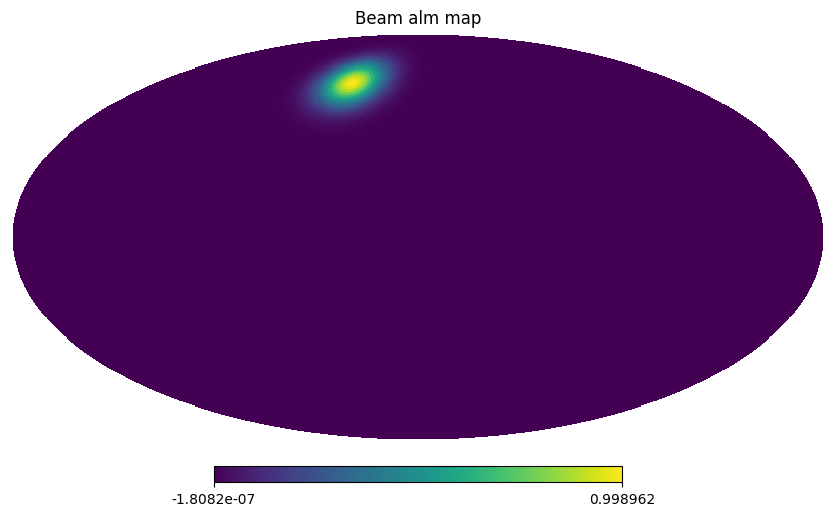

In [14]:
hp.mollview(hp.alm2map(a[1], nside=64), title='Beam alm map')